--- AUTOMATIC CALCULATED TABLE ---
    Funnel_Stage  User_Count  Conversion_Rate_%  Drop_off_Rate_%
0  1_Impressions      270000             100.00             0.00
1       2_Clicks       32000              11.85            88.15
2        3_Leads        7500               2.78            97.22
3  4_Add_to_Cart        2900               1.07            98.93
4    5_Purchased        1050               0.39            99.61


/tmp/ipykernel_887/2038701929.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='User_Count', y='Funnel_Stage', data=funnel_summary, palette='viridis')


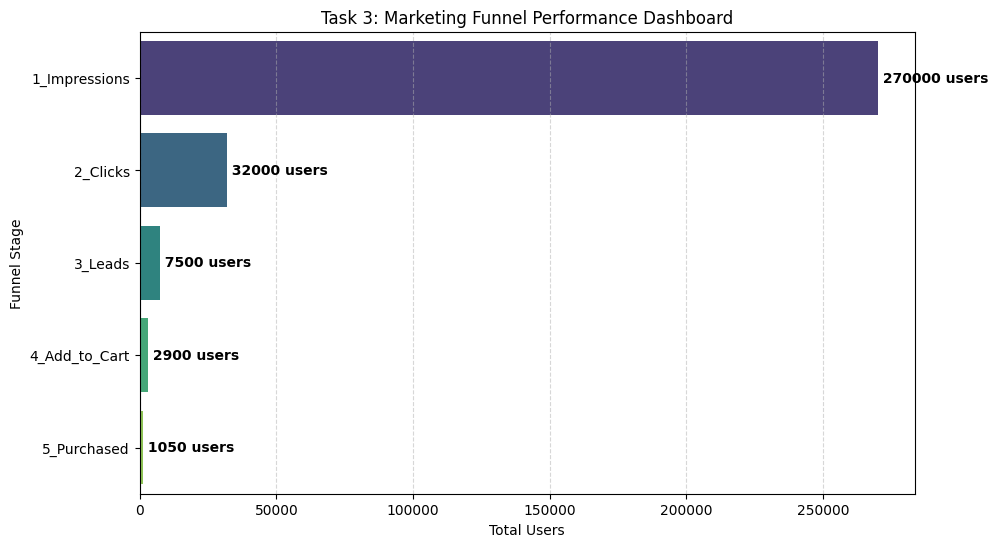

In [1]:
import pandas as pd
import io

# 1. Automatic Input Data Loading (Nuvvu data paste chesindi)
csv_data = """Marketing_Channel,Funnel_Stage,User_Count
Google Ads,1_Impressions,100000
Google Ads,2_Clicks,15000
Google Ads,3_Leads,3000
Google Ads,4_Add_to_Cart,1200
Google Ads,5_Purchased,400
Meta Ads,1_Impressions,150000
Meta Ads,2_Clicks,12000
Meta Ads,3_Leads,2500
Meta Ads,4_Add_to_Cart,800
Meta Ads,5_Purchased,200
Email Marketing,1_Impressions,20000
Email Marketing,2_Clicks,5000
Email Marketing,3_Leads,2000
Email Marketing,4_Add_to_Cart,900
Email Marketing,5_Purchased,450"""

df = pd.read_csv(io.StringIO(csv_data))

# 2. Automatically Aggregate Data (No manual math needed)
funnel_summary = df.groupby('Funnel_Stage')['User_Count'].sum().reset_index()

# 3. Calculate Rates Automatically
funnel_summary['Conversion_Rate_%'] = (funnel_summary['User_Count'] / funnel_summary['User_Count'].max() * 100).round(2)
funnel_summary['Drop_off_Rate_%'] = (100 - funnel_summary['Conversion_Rate_%']).round(2)

print("--- AUTOMATIC CALCULATED TABLE ---")
print(funnel_summary)

# 4. Generate the Task 3 Funnel Chart Automatically
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='User_Count', y='Funnel_Stage', data=funnel_summary, palette='viridis')
for index, value in enumerate(funnel_summary['User_Count']):
    plt.text(value, index, f" {int(value)} users", va='center', fontweight='bold')

plt.title('Task 3: Marketing Funnel Performance Dashboard')
plt.xlabel('Total Users')
plt.ylabel('Funnel Stage')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()